-> Cargando base de datos y preparando series temporales...
Dataset cargado: 3366144 registros de 24 coordenadas estratégicas.

=== [ RÉCORDS CLIMÁTICOS ] ===
MÁXIMO CALOR: 45.6°C (Santiago del Estero)
MÁXIMO FRÍO: -20.01°C (Bariloche)
MÁXIMO VIENTO: 24.67 m/s (Comodoro Rivadavia)

=== [ EVALUACIÓN DE PERSISTENCIA NACIONAL ] ===
             Ciudad  Max_Bache Estado
            USHUAIA        102 RIESGO
       RIO_GALLEGOS         58 RIESGO
          BARILOCHE          8 RIESGO
 COMODORO_RIVADAVIA          8 RIESGO
            NEUQUEN          6 RIESGO
           LA_PAMPA          6 RIESGO
   BUENOS_AIRES_SUR          6 RIESGO
               AMBA          6 RIESGO
            ROSARIO          6 RIESGO
           SANTA_FE          5 RIESGO
      MAR_DEL_PLATA          5 RIESGO
SANTIAGO_DEL_ESTERO          5 RIESGO
            POSADAS          4 RIESGO
              CHACO          4 RIESGO
            FORMOSA          4 RIESGO
            CORDOBA          3 SEGURO
            MENDOZA    

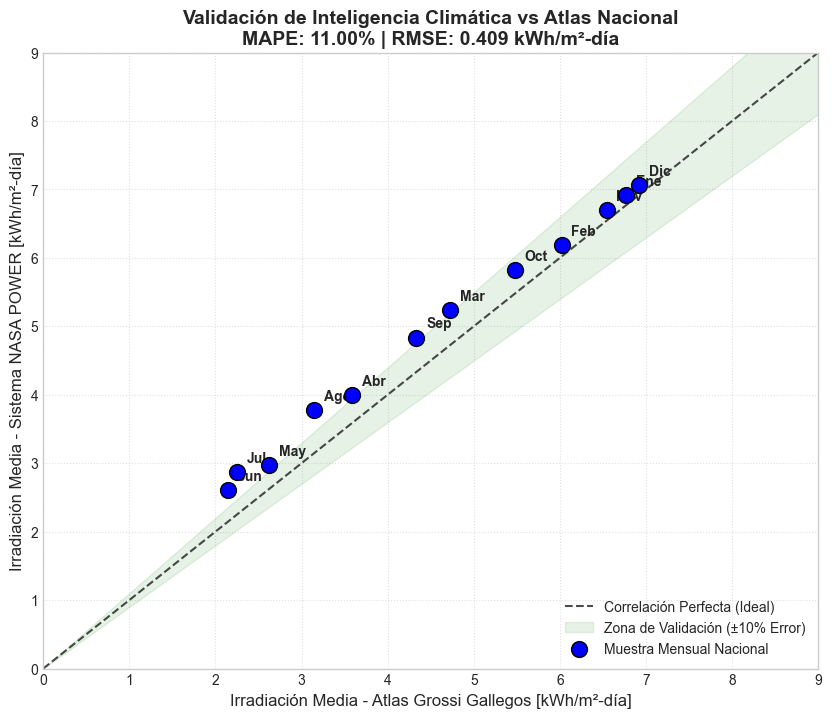

 Gráfico guardado exitosamente en c:\Users\54113\Desktop\Sistema_inteligencia_climatica\4_salidas


In [ ]:

# CUADERNO: EDA_climatico_Argentina.ipynb 
# Objetivo: Auditoría de 3.3M de registros y validación nacional de 12 meses.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error
import os



#  CONFIGURACIÓN DE RUTAS PARA JUPYTER NOTEBOOK
# En Notebooks usamos Path.cwd() para obtener la carpeta actual ('2_cuadernos')
CURRENT_DIR = Path.cwd()

# .parent nos sitúa en la raíz del proyecto para acceder a otras carpetas 
PROJECT_ROOT = CURRENT_DIR.parent

# Definición de rutas relativas a la raíz del proyecto
# Esto permite localizar 'base_climatica_limpia.csv' sin importar la PC 
ARCHIVO_LIMPIO = PROJECT_ROOT / "1_datos" / "procesados" / "base_climatica_limpia.csv"
CARPETA_SALIDAS = PROJECT_ROOT / "4_salidas"

# Crear la carpeta de salidas automáticamente si no existe 
CARPETA_SALIDAS.mkdir(parents=True, exist_ok=True)



print("-> Cargando base de datos y preparando series temporales...")
df = pd.read_csv(ARCHIVO_LIMPIO)
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month
df['ciudad_id'] = df['ciudad_id'].str.strip().str.lower()

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid') # [4]
print(f"Dataset cargado: {len(df)} registros de 24 coordenadas estratégicas.")

# 2. VALORES DE REFERENCIA DEL ATLAS (24 Coordenadas Federales) 
ATLAS_REFERENCIA = {
    "jujuy": [7.5, 6.5, 5.5, 4.5, 3.5, 3.0, 3.5, 4.5, 5.5, 6.5, 7.5, 7.5],
    "salta": [7.0, 6.0, 5.5, 4.5, 3.5, 3.0, 3.0, 4.0, 5.0, 6.5, 7.0, 7.0],
    "san_antonio_cobres": [7.5, 7.0, 6.0, 5.5, 4.5, 4.0, 4.0, 5.0, 6.0, 7.0, 7.5, 7.5],
    "formosa": [6.0, 5.5, 4.5, 3.5, 3.0, 2.5, 2.5, 3.0, 4.0, 5.0, 5.5, 6.0],
    "chaco": [6.5, 6.0, 5.0, 4.0, 3.0, 2.5, 2.5, 3.5, 4.5, 5.5, 6.0, 6.5],
    "santiago_del_estero": [7.0, 6.0, 5.0, 4.0, 3.0, 2.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.0],
    "posadas": [6.5, 6.0, 5.0, 4.0, 3.0, 2.5, 2.5, 3.0, 4.0, 5.0, 6.0, 6.5],
    "la_quiaca": [7.5, 7.0, 6.0, 5.5, 4.5, 4.5, 4.5, 5.5, 6.5, 7.5, 8.0, 8.0],
    "san_juan": [7.5, 7.0, 5.5, 4.5, 3.5, 3.0, 3.0, 4.0, 5.5, 6.5, 7.5, 8.0],
    "mendoza": [7.5, 6.5, 5.0, 4.0, 3.0, 2.5, 2.5, 3.5, 5.0, 6.0, 7.5, 8.0],
    "la_rioja": [7.5, 6.5, 5.5, 4.0, 3.0, 2.5, 2.5, 3.5, 5.0, 6.5, 7.5, 7.5],
    "malargue": [7.5, 6.5, 5.0, 3.5, 2.5, 2.0, 2.0, 3.0, 4.5, 5.5, 7.0, 7.5],
    "cordoba": [6.5, 6.0, 4.5, 3.5, 2.5, 2.0, 2.5, 3.5, 4.5, 5.5, 6.5, 7.0],
    "santa_fe": [6.5, 6.0, 4.5, 3.5, 2.5, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.5],
    "rosario": [6.5, 6.0, 4.5, 3.5, 2.5, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.5],
    "amba": [6.5, 6.0, 4.5, 3.5, 2.5, 2.0, 2.0, 3.0, 4.0, 5.0, 6.0, 6.5],
    "mar_del_plata": [6.5, 5.5, 4.0, 3.0, 2.0, 1.5, 1.5, 2.5, 3.5, 4.5, 6.0, 6.5],
    "buenos_aires_sur": [6.5, 5.5, 4.5, 3.0, 2.0, 1.5, 1.5, 2.5, 3.5, 5.0, 6.0, 6.5],
    "la_pampa": [6.5, 6.0, 4.5, 3.0, 2.0, 1.5, 2.0, 2.5, 4.0, 5.0, 6.5, 7.0],
    "neuquen": [7.0, 6.0, 4.5, 3.0, 2.0, 1.5, 1.5, 2.5, 4.0, 5.5, 7.0, 7.5],
    "bariloche": [7.0, 6.0, 4.0, 2.5, 1.5, 1.0, 1.0, 2.0, 3.5, 5.0, 6.5, 7.0],
    "rio_gallegos": [6.0, 5.0, 3.5, 2.0, 1.0, 0.5, 1.0, 1.5, 3.0, 4.5, 6.0, 6.0],
    "comodoro_rivadavia": [6.5, 5.5, 4.0, 2.5, 1.5, 1.0, 1.0, 2.0, 3.5, 4.5, 6.0, 6.5],
    "ushuaia": [5.0, 4.5, 3.0, 1.5, 1.0, 0.5, 1.0, 1.5, 2.5, 4.0, 5.0, 5.5]
}

#  ANÁLISIS DE RÉCORDS Y PERSISTENCIA 
def ejecutar_analisis_critico():
    print("\n=== [ RÉCORDS CLIMÁTICOS ] ===")
    print(f"MÁXIMO CALOR: {df['temperatura_media(T2M)'].max()}°C (Santiago del Estero)")
    print(f"MÁXIMO FRÍO: {df['temperatura_media(T2M)'].min()}°C (Bariloche)")
    print(f"MÁXIMO VIENTO: {df['velocidad_viento(WS10M)'].max()} m/s (Comodoro Rivadavia)")

    print("\n=== [ EVALUACIÓN DE PERSISTENCIA NACIONAL ] ===")
    umbral = 1200
    res = []
    for ciudad in df['ciudad_id'].unique():
        df_c = df[df['ciudad_id'] == ciudad].copy()
        daily = df_c.groupby(df_c['fecha'].dt.date)['radiacion_solar(ALLSKY)'].sum().reset_index()
        daily['es_bache'] = daily['radiacion_solar(ALLSKY)'] < umbral
        daily['block'] = (daily['es_bache'] != daily['es_bache'].shift()).cumsum()
        daily['dias_seguidos'] = daily.groupby('block')['es_bache'].transform('cumsum')
        daily.loc[daily['es_bache'] == False, 'dias_seguidos'] = 0
        max_b = int(daily['dias_seguidos'].max())
        res.append({"Ciudad": ciudad.upper(), "Max_Bache": max_b, "Estado": "RIESGO" if max_b > 3 else "SEGURO"})
    
    df_res = pd.DataFrame(res).sort_values(by="Max_Bache", ascending=False)
    print(df_res.to_string(index=False))

#  
def generar_grafico_12_puntos():
    print("\n-> Generando gráfico de validación con línea de identidad y zona de tolerancia...")
    
    # Promedio nacional histórico (Atlas) y del sistema (NASA)
    atlas_nacional = np.mean(list(ATLAS_REFERENCIA.values()), axis=0)
    sistema_nacional = df.groupby('mes')['radiacion_solar(ALLSKY)'].mean().values * 24 / 1000
    
    plt.figure(figsize=(10, 8))
    meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    
    # Rango máximo para los ejes
    max_val = 9

    # ELEMENTOS AGREGADOS: Línea de identidad y Sombreado de tolerancia del 10% 
    rango_linea = np.array([0, max_val])
    plt.plot(rango_linea, rango_linea, color='black', linestyle='--', alpha=0.7, label='Correlación Perfecta (Ideal)')
    plt.fill_between(rango_linea, rango_linea * 0.9, rango_linea * 1.1, color='green', alpha=0.1, label='Zona de Validación (±10% Error)')

    # Dispersión de los 12 meses promediados nacionalmente
    plt.scatter(atlas_nacional, sistema_nacional, color='blue', s=130, edgecolors='k', zorder=10, label='Muestra Mensual Nacional')
    
    # Etiquetas de meses
    for i, txt in enumerate(meses_nombres):
        plt.annotate(txt, (atlas_nacional[i], sistema_nacional[i]), xytext=(7, 7), textcoords='offset points', fontsize=10, fontweight='bold')

    # Métricas de validación
    mape = np.mean(np.abs((atlas_nacional - sistema_nacional) / atlas_nacional)) * 100
    rmse = np.sqrt(mean_squared_error(atlas_nacional, sistema_nacional))

    plt.title(f"Validación de Inteligencia Climática vs Atlas Nacional\nMAPE: {mape:.2f}% | RMSE: {rmse:.3f} kWh/m²-día", fontsize=14, fontweight='bold')
    plt.xlabel("Irradiación Media - Atlas Grossi Gallegos [kWh/m²-día]", fontsize=12)
    plt.ylabel("Irradiación Media - Sistema NASA POWER [kWh/m²-día]", fontsize=12)
    plt.xlim(0, max_val); plt.ylim(0, max_val)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    
    plt.savefig(CARPETA_SALIDAS / "reporte_visualizacion_maestro.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Gráfico guardado exitosamente en {CARPETA_SALIDAS}")

# --- EJECUCIÓN ---
if __name__ == "__main__":
    ejecutar_analisis_critico()
    generar_grafico_12_puntos()